HW 13

hw13作業請同學針對鐵達尼號沈船人員資料集，利用Logistic Regression、CART決策樹、及隨機森蓮模型進行人員存活預測分析。
1. 建立分類預測模型，計算評估效能，比較評估效能
2. 針對CART決策樹繪製樹圖
3. 以隨機森林模型計算特之因子重要性，並由大到小排序
4. 以隨機森林模型利用網格搜尋方法執行超參數分析（至少選３個特徵因子）

### 獲得鐵達尼資料

In [2]:
import pandas as pd
import kagglehub


# Download the latest version of a common Titanic dataset
path = kagglehub.dataset_download("yasserh/titanic-dataset")

# Load the CSV file (typically named 'Titanic-Dataset.csv' or similar)
# Adjust the filename based on the output of the list above
df = pd.read_csv(f"{path}/Titanic-Dataset.csv")
df.head()

Using Colab cache for faster access to the 'titanic-dataset' dataset.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 數據預處理 (Data Preprocessing)

In [3]:
print(df.info())
print('\nMissing values before handling:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values before handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          6

從 `info()` 和 `isnull().sum()` 的輸出中，我們可以觀察到：

*   **Age (年齡)**：有缺失值。我們可以對這些缺失值進行插補，例如使用年齡的中位數。
*   **Cabin (客艙)**：有大量的缺失值。最好直接刪除此欄位。
*   **Embarked (登船港口)**：有少量缺失值。我們可以使用最頻繁出現的港口來插補這些值。
*   **PassengerId (乘客ID)**、**Name (姓名)**、**Ticket (票號)**：這些欄位對於預測可能沒有用處，可以將其刪除。


In [4]:
# 刪除 'Cabin' (客艙), 'Name' (姓名), 'Ticket' (票號) 和 'PassengerId' (乘客ID) 欄位
# 使用 errors='ignore' 以避免在欄位已不存在時報錯
df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], errors='ignore')

# 使用中位數插補 'Age' (年齡) 的缺失值
df['Age'].fillna(df['Age'].median(), inplace=True)

# 使用眾數插補 'Embarked' (登船港口) 的缺失值
# 檢查 'Embarked' 欄位是否存在且有缺失值，避免重複處理或欄位不存在時報錯
if 'Embarked' in df.columns and df['Embarked'].isnull().any():
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print('\n處理後的缺失值總數:')
print(df.isnull().sum())


處理後的缺失值總數:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipykernel_1554/3762620555.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1554/3762620555.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

現在，將類別特徵 ('Sex' 性別, 'Embarked' 登船港口) 轉換為數值特徵，使用 One-Hot 編碼。

In [5]:
# 使用 One-Hot 編碼將 'Sex' (性別) 和 'Embarked' (登船港口) 轉換為數值型態
# 創建一個列表來存儲需要進行 one-hot 編碼的類別特徵，並檢查欄位是否存在
categorical_features_to_encode = []
if 'Sex' in df.columns:
    categorical_features_to_encode.append('Sex')
if 'Embarked' in df.columns:
    categorical_features_to_encode.append('Embarked')

# 如果有需要編碼的欄位，則執行 One-Hot 編碼
if categorical_features_to_encode:
    df = pd.get_dummies(df, columns=categorical_features_to_encode, drop_first=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


### 數據切分 (Data Splitting)

In [6]:
from sklearn.model_selection import train_test_split

# 定義特徵 (X) 和目標變數 (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# 將數據切分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train 的形狀: {X_train.shape}")
print(f"X_test 的形狀: {X_test.shape}")
print(f"y_train 的形狀: {y_train.shape}")
print(f"y_test 的形狀: {y_test.shape}")

X_train 的形狀: (623, 8)
X_test 的形狀: (268, 8)
y_train 的形狀: (623,)
y_test 的形狀: (268,)


### 建立與評估分類模型 (Build and Evaluate Classification Models)

我們將建立並評估三種分類模型：邏輯迴歸 (Logistic Regression)、CART 決策樹 (CART Decision Tree) 和隨機森林 (Random Forest)。

#### 1. 邏輯迴歸 (Logistic Regression)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 初始化並訓練邏輯迴歸模型
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)

# 進行預測
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# 評估模型性能
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print("邏輯迴歸模型性能:")
print(f"準確度 (Accuracy): {accuracy_lr:.4f}")
print(f"精確度 (Precision): {precision_lr:.4f}")
print(f"召回率 (Recall): {recall_lr:.4f}")
print(f"F1 分數 (F1-Score): {f1_lr:.4f}")
print(f"ROC AUC 分數: {roc_auc_lr:.4f}")

邏輯迴歸模型性能:
準確度 (Accuracy): 0.7985
精確度 (Precision): 0.7879
召回率 (Recall): 0.7027
F1 分數 (F1-Score): 0.7429
ROC AUC 分數: 0.8775


#### 2. CART 決策樹 (CART Decision Tree)

In [8]:
from sklearn.tree import DecisionTreeClassifier

# 初始化並訓練 CART 決策樹模型
cart_tree = DecisionTreeClassifier(random_state=42)
cart_tree.fit(X_train, y_train)

# 進行預測
y_pred_cart = cart_tree.predict(X_test)
y_proba_cart = cart_tree.predict_proba(X_test)[:, 1]

# 評估模型性能
accuracy_cart = accuracy_score(y_test, y_pred_cart)
precision_cart = precision_score(y_test, y_pred_cart)
recall_cart = recall_score(y_test, y_pred_cart)
f1_cart = f1_score(y_test, y_pred_cart)
roc_auc_cart = roc_auc_score(y_test, y_proba_cart)

print("CART 決策樹模型性能:")
print(f"準確度 (Accuracy): {accuracy_cart:.4f}")
print(f"精確度 (Precision): {precision_cart:.4f}")
print(f"召回率 (Recall): {recall_cart:.4f}")
print(f"F1 分數 (F1-Score): {f1_cart:.4f}")
print(f"ROC AUC 分數: {roc_auc_cart:.4f}")

CART 決策樹模型性能:
準確度 (Accuracy): 0.7463
精確度 (Precision): 0.6972
召回率 (Recall): 0.6847
F1 分數 (F1-Score): 0.6909
ROC AUC 分數: 0.7347


#### 3. 隨機森林 (Random Forest)

In [9]:
from sklearn.ensemble import RandomForestClassifier

# 初始化並訓練隨機森林模型
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

# 進行預測
y_pred_rf = random_forest.predict(X_test)
y_proba_rf = random_forest.predict_proba(X_test)[:, 1]

# 評估模型性能
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("隨機森林模型性能:")
print(f"準確度 (Accuracy): {accuracy_rf:.4f}")
print(f"精確度 (Precision): {precision_rf:.4f}")
print(f"召回率 (Recall): {recall_rf:.4f}")
print(f"F1 分數 (F1-Score): {f1_rf:.4f}")
print(f"ROC AUC 分數: {roc_auc_rf:.4f}")

隨機森林模型性能:
準確度 (Accuracy): 0.7799
精確度 (Precision): 0.7453
召回率 (Recall): 0.7117
F1 分數 (F1-Score): 0.7281
ROC AUC 分數: 0.8603


### 比較評估效能 (Compare Evaluation Performance)

In [10]:
import pandas as pd

performance_data = {
    '模型 (Model)': ['邏輯迴歸 (Logistic Regression)', 'CART 決策樹 (CART Decision Tree)', '隨機森林 (Random Forest)'],
    '準確度 (Accuracy)': [accuracy_lr, accuracy_cart, accuracy_rf],
    '精確度 (Precision)': [precision_lr, precision_cart, precision_rf],
    '召回率 (Recall)': [recall_lr, recall_cart, recall_rf],
    'F1 分數 (F1-Score)': [f1_lr, f1_cart, f1_rf],
    'ROC AUC 分數 (ROC AUC Score)': [roc_auc_lr, roc_auc_cart, roc_auc_rf]
}

performance_df = pd.DataFrame(performance_data)
print(performance_df.round(4).to_markdown(index=False))

| 模型 (Model)                     |   準確度 (Accuracy) |   精確度 (Precision) |   召回率 (Recall) |   F1 分數 (F1-Score) |   ROC AUC 分數 (ROC AUC Score) |
|:---------------------------------|--------------------:|---------------------:|------------------:|---------------------:|-------------------------------:|
| 邏輯迴歸 (Logistic Regression)   |              0.7985 |               0.7879 |            0.7027 |               0.7429 |                         0.8775 |
| CART 決策樹 (CART Decision Tree) |              0.7463 |               0.6972 |            0.6847 |               0.6909 |                         0.7347 |
| 隨機森林 (Random Forest)         |              0.7799 |               0.7453 |            0.7117 |               0.7281 |                         0.8603 |


### 解決 Matplotlib 中文字體顯示問題 (Solve Matplotlib Chinese Font Display Issue)

In [11]:
# 安裝中文字體 (以思源黑體為例)
!pip install font-manager
!sudo apt-get install -y fonts-noto-cjk

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 找到系統中的思源黑體 (Noto Sans CJK TC)
# 如果找不到，可能需要手動指定字體路徑
font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc' # 或 'NotoSansCJKtc-Regular.otf'
if not fm.findfont(fm.FontProperties(fname=font_path)):
    # 嘗試另一個常見路徑，如果上述路徑無效則使用備用字體
    font_path = '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc' # Colab 中的另一個常見路徑
    if not fm.findfont(fm.FontProperties(fname=font_path)):
        print("警告: 在常見路徑中找不到 NotoSansCJK-Regular.ttc。正在嘗試尋找其他 CJK 字體。")
        # 備用為通用 CJK 字體或顯示錯誤
        matching_fonts = fm.findfont(fm.FontProperties(family='Noto Sans CJK'))
        if matching_fonts:
            font_path = matching_fonts
            print(f"找到 CJK 字體: {font_path}")
        else:
            print("錯誤: 未找到 CJK 字體。將使用預設字體繪圖，這可能無法正確顯示中文字符。")
            font_path = None

if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['axes.unicode_minus'] = False # 解決負號顯示問題
    print("Matplotlib 已配置中文字體。")
else:
    print("Matplotlib 未能成功配置中文字體，請手動檢查字體安裝和路徑。")

# 決策樹繪圖程式碼已移至此單元格之後的獨立單元格，以確保中文字體配置生效。

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 12.1 MB/s eta 0:00:00
  Created wheel for font-manager: filename=font_manager-0.1.0-py3-none-any.whl size=72603 sha256=cc502a03c71cf4d39bb50a7f124a784109ee12b8a90922e16c69d1237cef5710
  Stored in directory: /root/.cache/pip/wheels/13/75/0d/1541b25b46e6f40fddf6911f9d0f7f5a5b4a4f2b94df4afd8a
Successfully built font-manager
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additiona

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io
import base64
from google.colab import drive
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseUpload

# Mount Google Drive to save the plot
def mount_drive():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully!")
    except Exception as e:
        print(f"Error mounting Google Drive: {e}")

# Authenticate to Google Cloud to use Google Drive API
def authenticate_gcs():
    try:
        auth.authenticate_user()
        print("Google Cloud authenticated successfully!")
    except Exception as e:
        print(f"Error authenticating Google Cloud: {e}")

# Function to upload matplotlib plot to Google Drive
def upload_plt_to_gcs(num_fig, step, fig):
    mount_drive()
    authenticate_gcs()

    # Convert plot to PNG image in memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.1)
    buf.seek(0)

    # Get Drive service
    service = build('drive', 'v3')

    # Create a folder in Google Drive if it doesn't exist
    folder_name = 'colab_generated_plots'
    folder_id = None
    response = service.files().list(
        q=f"name='{folder_name}' and mimeType='application/vnd.google-apps.folder'",
        spaces='drive'
    ).execute()

    for file in response.get('files', []):
        if file.get('name') == folder_name:
            folder_id = file.get('id')
            break

    if not folder_id:
        file_metadata = {
            'name': folder_name,
            'mimeType': 'application/vnd.google-apps.folder'
        }
        folder = service.files().create(body=file_metadata, fields='id').execute()
        folder_id = folder.get('id')
        print(f"Created folder '{folder_name}' with ID: {folder_id}")
    else:
        print(f"Folder '{folder_name}' already exists with ID: {folder_id}")

    # Prepare file metadata and upload
    file_name = f'plot_step_{step}_{num_fig}.png'
    file_metadata = {
        'name': file_name,
        'parents': [folder_id]
    }
    media = MediaIoBaseUpload(buf, mimetype='image/png', resumable=True)
    uploaded_file = service.files().create(body=file_metadata, media_body=media, fields='id').execute()
    print(f"Uploaded plot '{file_name}' to Google Drive with ID: {uploaded_file.get('id')}")

### 針對CART決策樹繪製樹圖 (Draw the tree diagram for the CART decision tree)

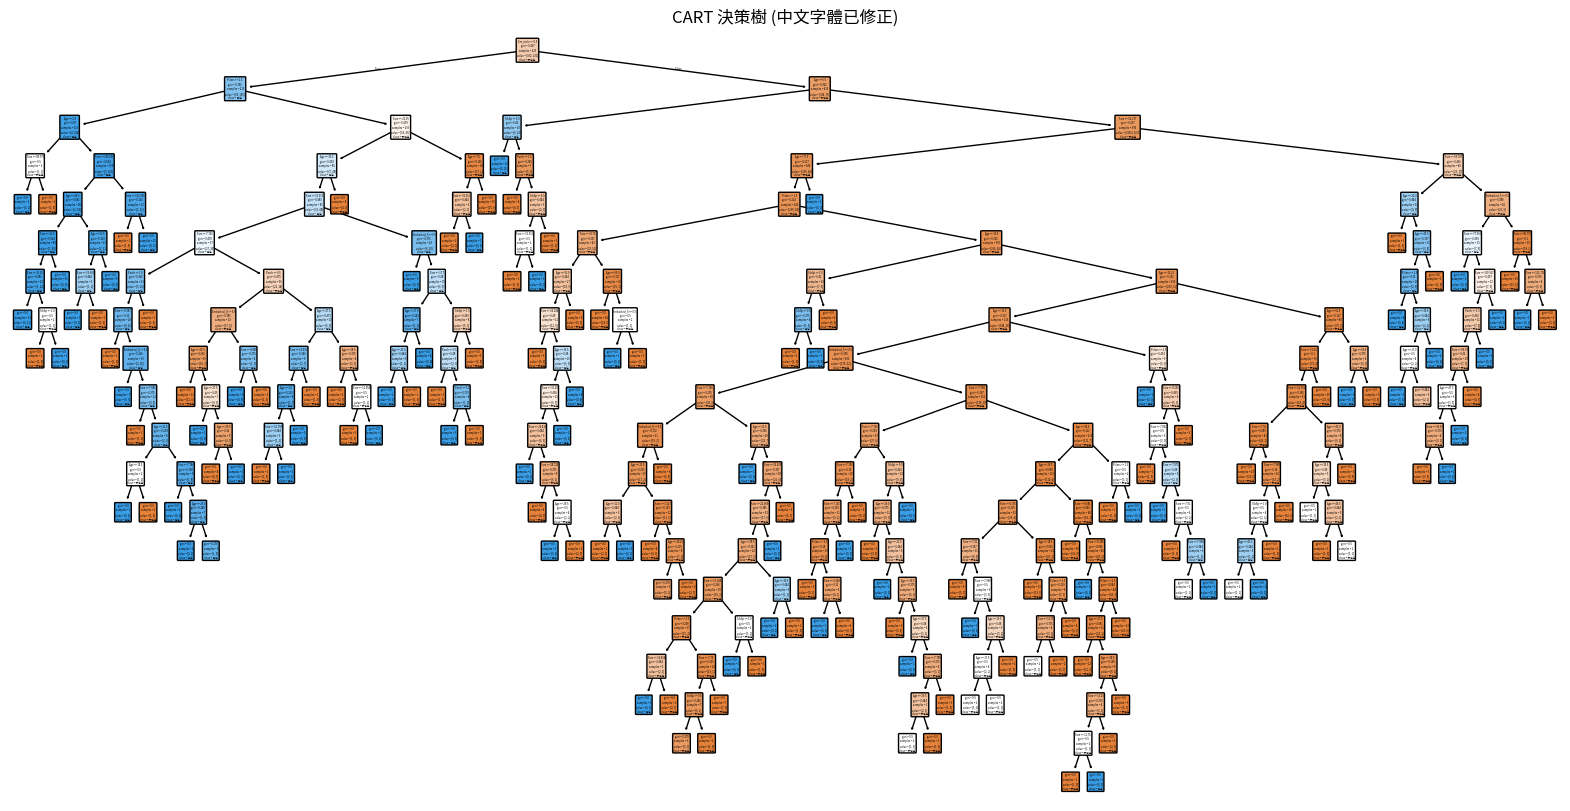

In [12]:
from sklearn.tree import plot_tree

# 繪製 CART 決策樹
plt.figure(figsize=(20, 10))
plot_tree(cart_tree, feature_names=X.columns, class_names=['未倖存', '倖存'], filled=True, rounded=True)
plt.title("CART 決策樹 (中文字體已修正)")
plt.show()

### 以隨機森林模型計算特徵因子重要性，並由大到小排序 (Calculate feature importance for the Random Forest model and sort it from largest to smallest)

In [13]:
import pandas as pd

# 從隨機森林模型中獲取特徵重要性
feature_importances = random_forest.feature_importances_

# 創建一個 DataFrame 以便於視覺化
features_df = pd.DataFrame({
    '特徵 (Feature)': X.columns,
    '重要性 (Importance)': feature_importances
})

# 按照重要性降序排序
features_df = features_df.sort_values(by='重要性 (Importance)', ascending=False)

print("隨機森林特徵重要性 (已排序):")
print(features_df.to_markdown(index=False))

隨機森林特徵重要性 (已排序):
| 特徵 (Feature)   |   重要性 (Importance) |
|:-----------------|----------------------:|
| Fare             |             0.270981  |
| Sex_male         |             0.255571  |
| Age              |             0.255166  |
| Pclass           |             0.0861763 |
| SibSp            |             0.0553162 |
| Parch            |             0.0405304 |
| Embarked_S       |             0.0244969 |
| Embarked_Q       |             0.0117621 |


/tmp/ipykernel_1554/3265648938.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='特徵 (Feature)', y='重要性 (Importance)', data=features_df, palette='magma')


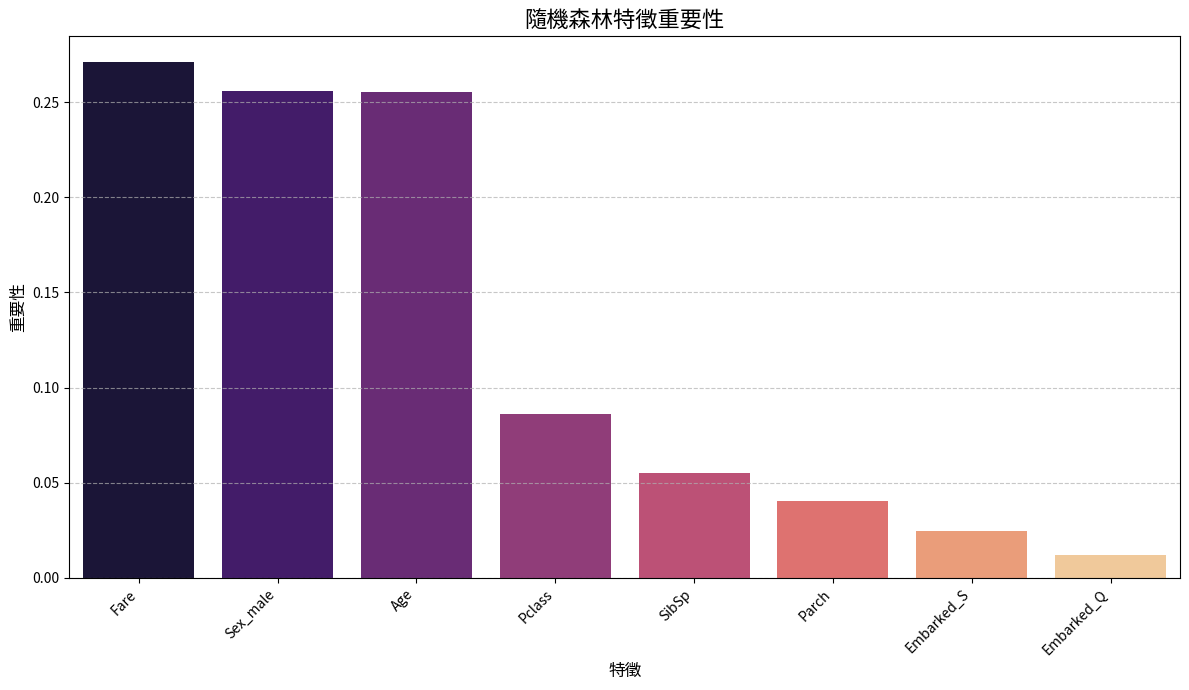

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 繪製特徵重要性長條圖
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='特徵 (Feature)', y='重要性 (Importance)', data=features_df, palette='magma')
plt.title('隨機森林特徵重要性', fontsize=16)
plt.xlabel('特徵', fontsize=12)
plt.ylabel('重要性', fontsize=12)
plt.xticks(rotation=45, ha='right') # 旋轉x軸標籤以避免重疊
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # 自動調整布局以避免標籤重疊
plt.show()

### 以隨機森林模型利用網格搜尋方法執行超參數分析 (Perform hyperparameter tuning for the Random Forest model using Grid Search)

In [14]:
from sklearn.model_selection import GridSearchCV

# 定義隨機森林的超參數網格
# 選擇至少 3 個參數進行調優
param_grid = {
    'n_estimators': [100, 200, 300],  # 森林中樹的數量
    'max_depth': [None, 10, 20],      # 樹的最大深度
    'min_samples_split': [2, 5, 10],  # 分割內部節點所需的最少樣本數
    'min_samples_leaf': [1, 2, 4]     # 葉節點所需的最少樣本數
}

# 初始化 GridSearchCV
# 我們將使用之前定義的 RandomForestClassifier (random_forest) 作為估計器
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid,
                            cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# 將 GridSearchCV 擬合到訓練數據
grid_search_rf.fit(X_train, y_train)

# 獲取最佳參數和最佳分數
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print("隨機森林網格搜尋結果:")
print(f"最佳參數: {best_params_rf}")
print(f"最佳交叉驗證準確度: {best_score_rf:.4f}")

# 在測試集上評估最佳模型
best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
y_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf)
recall_best_rf = recall_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)
roc_auc_best_rf = roc_auc_score(y_test, y_proba_best_rf)

print("\n最佳隨機森林模型性能 (在測試集上):")
print(f"準確度 (Accuracy): {accuracy_best_rf:.4f}")
print(f"精確度 (Precision): {precision_best_rf:.4f}")
print(f"召回率 (Recall): {recall_best_rf:.4f}")
print(f"F1 分數 (F1-Score): {f1_best_rf:.4f}")
print(f"ROC AUC 分數: {roc_auc_best_rf:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
隨機森林網格搜尋結果:
最佳參數: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
最佳交叉驗證準確度: 0.8282

最佳隨機森林模型性能 (在測試集上):
準確度 (Accuracy): 0.8097
精確度 (Precision): 0.8409
召回率 (Recall): 0.6667
F1 分數 (F1-Score): 0.7437
ROC AUC 分數: 0.8760
